In [5]:
import numpy as np
import pandas as pd

## Trials for N=3

In [51]:
LAMBDAS = np.zeros((6, 3))
LAMBDAS[0] = np.array((1, 0, 0))
for i in range(1, 6):
    decr = 6-i#2
    lam_try = np.array((1, 1/decr, 1/(decr*decr)))
    lam_try_normalized = lam_try / lam_try.sum()
    LAMBDAS[i] = lam_try_normalized
LAMBDAS

array([[1.        , 0.        , 0.        ],
       [0.80645161, 0.16129032, 0.03225806],
       [0.76190476, 0.19047619, 0.04761905],
       [0.69230769, 0.23076923, 0.07692308],
       [0.57142857, 0.28571429, 0.14285714],
       [0.33333333, 0.33333333, 0.33333333]])

In [52]:
# Helper function to make truncated string repr of ndarray of floats
truncate_arr = lambda arr: '[' + ', '.join([str(x)[:4] for x in arr]) + ']'

(75, 90)

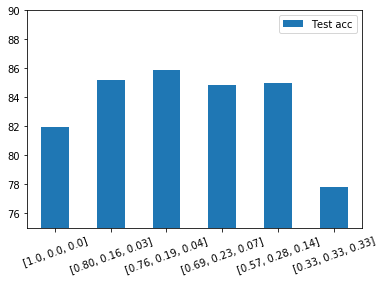

In [54]:
test_accs_1 = {truncate_arr(k):v for k, v in zip(LAMBDAS, [81.96, 85.22, 85.85, 84.81, 84.99, 77.79])}
test_accs_df = pd.DataFrame(test_accs_1, index=["Test acc"]).T
ax = test_accs_df.plot.bar(rot=20)
ax.set_ylim(75,90)

## N=2 vs. N=3

The question now would be: is mixup with 2 components better than with 3 components?

We found the sweet lambda spot for mixup with N=3 around [0.75, 0.20, 0.05].

We will use this as a baseline to compare against the sweet lambda spot for mixup with N=2: [0.75, 0.25, 0], and an additional no-mixup benchmark

We run 3 trials on each.

In [55]:
test_accs_2 = {'[1. 0. 0.]': 82.5,
 '[0.75 0.2  0.05]': 85.25,
 '[0.75 0.25 0.  ]': 86.23,
 '[0.05 0.75 0.2 ]': 85.71,
 '[0.   0.75 0.25]': 86.4,
 '[0.2  0.05 0.75]': 85.74,
 '[0.25 0.   0.75]': 86.39}

(80, 90)

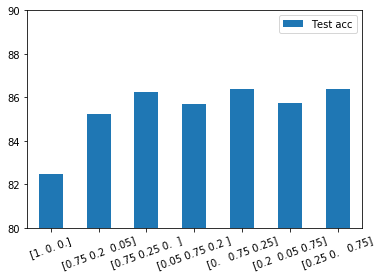

In [56]:
test_accs_df = pd.DataFrame(test_accs_2, index=["Test acc"]).T
ax = test_accs_df.plot.bar(rot=20)
ax.set_ylim(80,90)

<u>Observations</u>: 
 - The best results were consistently yielded by lambda vectors N=2 rather than N=3
 - Performance of no-mixup benchmark is worse than all the other trials nonetheless, as is to be expected

## Trials for N=4

In [57]:
LAMBDAS = np.zeros((6, 4))
LAMBDAS[0] = np.array((1, 0, 0, 0))
for i in range(1, 6):
    decr = 6-i#2
    lam_try = np.array((1, 1/decr, 1/(decr*decr), 1/(decr*decr)))
    lam_try_normalized = lam_try / lam_try.sum()
    LAMBDAS[i] = lam_try_normalized
LAMBDAS

array([[1.        , 0.        , 0.        , 0.        ],
       [0.78125   , 0.15625   , 0.03125   , 0.03125   ],
       [0.72727273, 0.18181818, 0.04545455, 0.04545455],
       [0.64285714, 0.21428571, 0.07142857, 0.07142857],
       [0.5       , 0.25      , 0.125     , 0.125     ],
       [0.25      , 0.25      , 0.25      , 0.25      ]])

In [2]:
# Helper function to truncate string repr. of ndarray of floats
truncate_arrstr = lambda arrstr: '[' + ', '.join([s[:4] for s in arrstr[1:-1].split(' ')]) + ']'

In [59]:
test_accs_3 = {'[1. 0. 0. 0.]': 82.3,
 '[0.78125 0.15625 0.03125 0.03125]': 84.73,
 '[0.72727273 0.18181818 0.04545455 0.04545455]': 84.66,
 '[0.64285714 0.21428571 0.07142857 0.07142857]': 85.62,
 '[0.5   0.25  0.125 0.125]': 81.58,
 '[0.25 0.25 0.25 0.25]': 70.38}
test_accs_3 = {truncate_arrstr(k):v for k, v in test_accs_3.items()}

(65, 90)

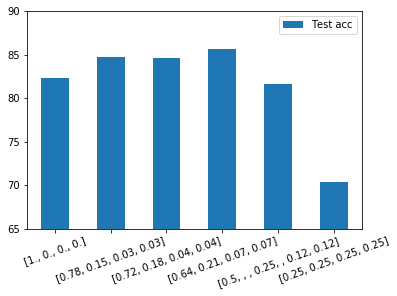

In [60]:
test_accs_df = pd.DataFrame(test_accs_3, index=["Test acc"]).T
ax = test_accs_df.plot.bar(rot=20)
ax.set_ylim(65,90)

<u>Observations</u>: 
 - The best results were yielded by lambda vector [0.64285714 0.21428571 0.07142857 0.07142857]
 - Performance of flat lambda vector is considerably worse than with N=3 but still way larger than random guess benchmark of 10%. In exchange, images at this point are very obfuscated

## Second batch of trials for N=4

In [3]:
test_accs_4 = {'[0.80128205 0.16025641 0.03205128 0.00641026]':  85.38,
 '[0.75294118 0.18823529 0.04705882 0.01176471]': 84.18,
 '[0.675 0.225 0.075 0.025]':  85.56,
 '[0.53333333 0.26666667 0.13333333 0.06666667]': 83.88,
 '[0.25 0.25 0.25 0.25]': 69.1}
test_accs_4 = {truncate_arrstr(k):v for k, v in test_accs_4.items()}

(65, 90)

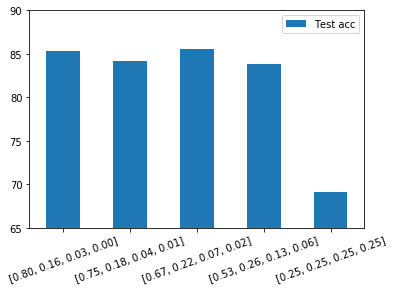

In [7]:
test_accs_df = pd.DataFrame(test_accs_4, index=["Test acc"]).T
ax = test_accs_df.plot.bar(rot=20)
ax.set_ylim(65,90)

<u>Observations</u>: 
 - Similarly, the best results were yielded by lambda vector [0.675 0.225 0.075 0.025]
 - Similarly, performance of flat lambda vector is considerably worse than with N=3 but still way larger than random guess benchmark of 10%.

Follow-up:
    
- presentation
- focus on maximizing absolute performance or maximizing performance given a level of privacy?

## TODO
- linear mixing, N=2 to 5
- 3*3 convolution kernel
- 75/25 CIFAR100 and Fashion-MNIST
- 11th class of random noise
- N=10 with all classes

## Pb: Increase accuracy, explore mixup (lack of empirical experiments)
- model, datasets
- how to mix
- N=2 increase performance
- N>2 worse
- interclass worse
